In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

In [2]:
PROJECT = Path("/mnt/d/Ibnu/riboseq/AT")
TABLES = PROJECT / "TABLES"

ANNOTATION_IN = TABLES / "annotation.10pct.tsv"
SALMON_IN = TABLES / "salmon_transcript.10pct.tsv"
TE_IN = TABLES / "translation_efficiency.10pct.tsv"

MASTER_OUT = TABLES / "master_transcript.10pct.tsv"

In [3]:
annotation = pd.read_csv(ANNOTATION_IN, sep="\t")
salmon = pd.read_csv(SALMON_IN, sep="\t")
te = pd.read_csv(TE_IN, sep="\t")

print(annotation.shape)
print(salmon.shape)
print(te.shape)

(52270, 11)
(59051, 8)
(59051, 14)


In [4]:
te_small = te[[
    "Transcript_ID",
    "RNA_prop",
    "Ribo_prop",
    "log2_RNA_prop",
    "log2_Ribo_prop",
    "Expected_log2_Ribo_prop",
    "TE_residual",
]].copy()

te_small.head()

,Transcript_ID,RNA_prop,Ribo_prop,log2_RNA_prop,log2_Ribo_prop,Expected_log2_Ribo_prop,TE_residual
0,AT1G01010.1,0.000004,0.000003,-17.78561,-18.490001,-17.787554,-0.702447
1,AT1G01020.2,0.000006,0.000000,NaN,NaN,NaN,NaN
2,AT1G01020.6,0.000000,0.000000,NaN,NaN,NaN,NaN
3,AT1G01020.1,0.000016,0.000000,NaN,NaN,NaN,NaN
4,AT1G01020.3,0.000000,0.000000,NaN,NaN,NaN,NaN


In [5]:
master = (
    annotation
    .merge(salmon, on=["Transcript_ID", "Gene_ID"], how="left")
    .merge(te_small, on="Transcript_ID", how="left")
)

print(master.shape)
master.head()

(52270, 23)


,Transcript_ID,Gene_ID,Chr,Strand,Transcript_start,Transcript_end,Transcript_length,UTR5_length,CDS_length,UTR3_length,...,Ribo_TPM,RNA_TPM,Ribo_Length,RNA_Length,RNA_prop,Ribo_prop,log2_RNA_prop,log2_Ribo_prop,Expected_log2_Ribo_prop,TE_residual
0,AT1G01010.1,AT1G01010,Chr1,+,3631,5899,1688,129,1290,269,...,0.111252,3.472288,1438.0,1438.0,0.000004,0.000003,-17.78561,-18.490001,-17.787554,-0.702447
1,AT1G01020.2,AT1G01020,Chr1,-,6788,8737,167,71,576,0,...,0.000000,7.810271,837.0,837.0,0.000006,0.000000,NaN,NaN,NaN,NaN
2,AT1G01020.6,AT1G01020,Chr1,-,6788,8737,144,144,315,0,...,0.000000,0.000000,694.0,694.0,0.000000,0.000000,NaN,NaN,NaN,NaN
3,AT1G01020.1,AT1G01020,Chr1,-,6788,9130,0,464,738,0,...,0.000000,16.592177,1079.0,1079.0,0.000016,0.000000,NaN,NaN,NaN,NaN
4,AT1G01020.4,AT1G01020,Chr1,-,6788,9130,0,0,711,0,...,0.000000,0.000000,1147.0,1147.0,0.000000,0.000000,NaN,NaN,NaN,NaN


In [6]:
print("Shape:", master.shape)
print()
print("Missing values:")
print(master.isna().sum())
print()
print("Duplicated Transcript_ID:", master["Transcript_ID"].duplicated().sum())

Shape: (52270, 23)

Missing values:
Transcript_ID                  0
Gene_ID                        0
Chr                            0
Strand                         0
Transcript_start               0
Transcript_end                 0
Transcript_length              0
UTR5_length                    0
CDS_length                     0
UTR3_length                    0
UTR_length                     0
Ribo_NumReads                  0
RNA_NumReads                   0
Ribo_TPM                       0
RNA_TPM                        0
Ribo_Length                    0
RNA_Length                     0
RNA_prop                       0
Ribo_prop                      0
log2_RNA_prop              37722
log2_Ribo_prop             37722
Expected_log2_Ribo_prop    37722
TE_residual                37722
dtype: int64

Duplicated Transcript_ID: 0


In [7]:
master.to_csv(MASTER_OUT, sep="\t", index=False)

print(MASTER_OUT)
print("Saved:", MASTER_OUT.exists())
print(master.shape)

/mnt/d/Ibnu/riboseq/AT/TABLES/master_transcript.10pct.tsv
Saved: True
(52270, 23)


In [8]:
# ============================================
# Statistical summary
# ============================================

print("=" * 80)
print("MASTER TABLE")
print("=" * 80)
print(f"Shape: {master.shape}")

print("\n")
print("=" * 80)
print("COLUMN INFORMATION")
print("=" * 80)
master.info()

print("\n")
print("=" * 80)
print("MISSING VALUES")
print("=" * 80)
display(
    master.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing")
)

numeric_cols = master.select_dtypes(include="number").columns

print("\n")
print("=" * 80)
print("NUMERIC SUMMARY")
print("=" * 80)
display(master[numeric_cols].describe().T)

print("\n")
print("=" * 80)
print("ZERO VALUE SUMMARY")
print("=" * 80)

zero_summary = pd.DataFrame({
    "Zero_count": (master[numeric_cols] == 0).sum(),
    "Zero_fraction": (master[numeric_cols] == 0).mean(),
})

display(
    zero_summary.sort_values(
        by="Zero_fraction",
        ascending=False,
    )
)

print("\n")
print("=" * 80)
print("FEATURE SUMMARY")
print("=" * 80)

summary = pd.DataFrame({
    "Minimum": master[numeric_cols].min(),
    "Median": master[numeric_cols].median(),
    "Mean": master[numeric_cols].mean(),
    "Maximum": master[numeric_cols].max(),
    "Std": master[numeric_cols].std(),
})

display(summary)

print("\n")
print("=" * 80)
print("TOP 10 TRANSCRIPTS BY RNA TPM")
print("=" * 80)
display(
    master.nlargest(
        10,
        "RNA_TPM",
    )[[
        "Transcript_ID",
        "Gene_ID",
        "RNA_TPM",
        "Ribo_TPM",
        "TE_residual",
    ]]
)

print("\n")
print("=" * 80)
print("TOP 10 TRANSCRIPTS BY RIBO TPM")
print("=" * 80)
display(
    master.nlargest(
        10,
        "Ribo_TPM",
    )[[
        "Transcript_ID",
        "Gene_ID",
        "RNA_TPM",
        "Ribo_TPM",
        "TE_residual",
    ]]
)

print("\n")
print("=" * 80)
print("TOP 10 TRANSCRIPTS BY TE RESIDUAL")
print("=" * 80)
display(
    master.nlargest(
        10,
        "TE_residual",
    )[[
        "Transcript_ID",
        "Gene_ID",
        "RNA_TPM",
        "Ribo_TPM",
        "TE_residual",
    ]]
)

MASTER TABLE
Shape: (52270, 23)


COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52270 entries, 0 to 52269
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Transcript_ID            52270 non-null  object 
 1   Gene_ID                  52270 non-null  object 
 2   Chr                      52270 non-null  object 
 3   Strand                   52270 non-null  object 
 4   Transcript_start         52270 non-null  int64  
 5   Transcript_end           52270 non-null  int64  
 6   Transcript_length        52270 non-null  int64  
 7   UTR5_length              52270 non-null  int64  
 8   CDS_length               52270 non-null  int64  
 9   UTR3_length              52270 non-null  int64  
 10  UTR_length               52270 non-null  int64  
 11  Ribo_NumReads            52270 non-null  float64
 12  RNA_NumReads             52270 non-null  float64
 13  Ribo_TPM               

,Missing
Expected_log2_Ribo_prop,37722
log2_Ribo_prop,37722
log2_RNA_prop,37722
TE_residual,37722
Transcript_ID,0
Gene_ID,0
Chr,0
Transcript_length,0
Transcript_end,0
Transcript_start,0




NUMERIC SUMMARY


,count,mean,std,min,25%,50%,75%,max
Transcript_start,52270.0,1.240392e+07,7.924096e+06,273.000000,5.656632e+06,1.173721e+07,1.847421e+07,3.042442e+07
Transcript_end,52270.0,1.240655e+07,7.924114e+06,734.000000,5.658228e+06,1.173909e+07,1.847638e+07,3.042519e+07
Transcript_length,52270.0,1.109218e+03,9.645669e+02,0.000000,4.690000e+02,8.760000e+02,1.479000e+03,1.519500e+04
UTR5_length,52270.0,1.550084e+02,2.064313e+02,0.000000,0.000000e+00,9.700000e+01,2.260000e+02,3.680000e+03
CDS_length,52270.0,1.199740e+03,1.004374e+03,0.000000,5.520000e+02,1.014000e+03,1.572000e+03,1.620300e+04
UTR3_length,52270.0,1.941178e+02,2.338795e+02,0.000000,0.000000e+00,1.650000e+02,2.940000e+02,4.001000e+03
UTR_length,52270.0,3.491262e+02,3.180752e+02,0.000000,7.900000e+01,3.150000e+02,5.190000e+02,4.857000e+03
Ribo_NumReads,52270.0,8.199442e+00,1.239695e+02,0.000000,0.000000e+00,0.000000e+00,2.018500e+00,2.263641e+04
RNA_NumReads,52270.0,8.131768e+01,4.944529e+02,0.000000,0.000000e+00,2.858000e+00,5.116800e+01,6.275156e+04
Ribo_TPM,52270.0,1.839925e+00,1.411350e+02,0.000000,0.000000e+00,0.000000e+00,1.428400e-01,3.113277e+04




ZERO VALUE SUMMARY


...

,Transcript_ID,Gene_ID,RNA_TPM,Ribo_TPM,TE_residual
5479,AT1G29930.1,AT1G29930,16827.495437,129.065446,1.659695
1364,AT1G07600.1,AT1G07600,10140.013383,157.742860,-0.517156
12909,AT1G79040.1,AT1G79040,8212.171781,213.157502,2.695165
19073,AT2G34420.1,AT2G34420,7410.222020,67.949778,1.355234
38044,AT4G28755.1,AT4G28755,5435.890542,0.000000,NaN
10754,AT1G67090.1,AT1G67090,5406.449862,0.000000,NaN
29085,AT3G47470.1,AT3G47470,4499.241885,24.341526,0.470864
21167,AT2G45180.1,AT2G45180,4271.917282,46.994264,1.262983
46490,AT5G38410.1,AT5G38410,4269.405161,71.524190,2.026558
23228,AT3G08520.1,AT3G08520,3935.398376,142.632073,0.930763




TOP 10 TRANSCRIPTS BY RIBO TPM


,Transcript_ID,Gene_ID,RNA_TPM,Ribo_TPM,TE_residual
13338,AT2G01021.1,AT2G01021,0.000000,31132.770551,NaN
52096,ATCG00570.1,ATCG00570,0.000000,3863.222984,NaN
52094,ATCG00550.1,ATCG00550,63.608106,2865.432221,8.146991
52074,ATCG00220.1,ATCG00220,0.000000,2387.680771,NaN
52064,ATCG00080.1,ATCG00080,0.000000,2266.320315,NaN
52067,ATCG00140.1,ATCG00140,43.246136,2119.283951,8.868401
52107,ATCG00690.1,ATCG00690,0.000000,1986.717773,NaN
52063,ATCG00070.1,ATCG00070,0.000000,1965.040396,NaN
52095,ATCG00560.1,ATCG00560,0.000000,1925.155620,NaN
52100,ATCG00630.1,ATCG00630,231.163455,1794.218464,6.367011




TOP 10 TRANSCRIPTS BY TE RESIDUAL


,Transcript_ID,Gene_ID,RNA_TPM,Ribo_TPM,TE_residual
52088,ATCG00490.1,ATCG00490,10.158554,1521.589831,11.971135
52075,ATCG00270.1,ATCG00270,4.854631,337.151844,10.250338
52060,ATCG00020.1,ATCG00020,31.716924,1074.896206,10.240220
52080,ATCG00350.1,ATCG00350,2.361634,144.825815,10.170399
52076,ATCG00280.1,ATCG00280,7.175355,306.105981,9.961050
52079,ATCG00340.1,ATCG00340,4.167119,135.246142,9.549269
52106,ATCG00680.1,ATCG00680,4.321648,118.763890,9.096561
52111,ATCG00730.1,ATCG00730,6.767314,262.628886,8.910362
52067,ATCG00140.1,ATCG00140,43.246136,2119.283951,8.868401
52065,ATCG00120.1,ATCG00120,3.712993,79.864663,8.658913


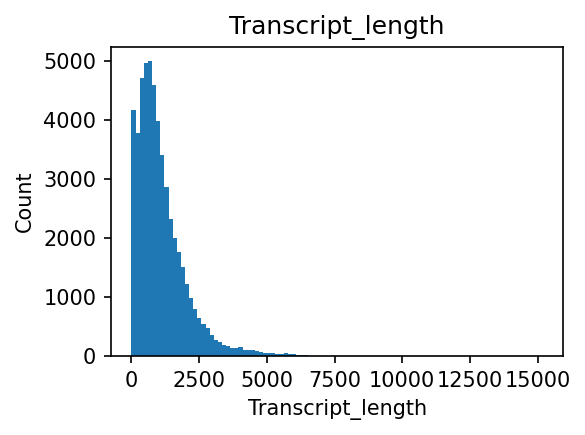

Transcript_length
count    52270.000000
mean      1109.218213
std        964.566900
min          0.000000
25%        469.000000
50%        876.000000
75%       1479.000000
max      15195.000000
Name: Transcript_length, dtype: float64
Skewness : 2.332
Kurtosis : 11.198



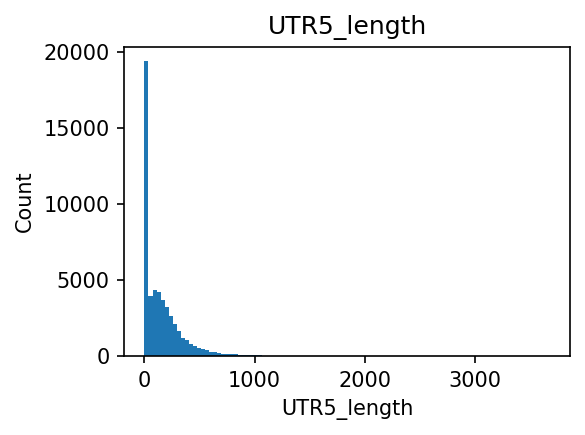

UTR5_length
count    52270.00000
mean       155.00838
std        206.43128
min          0.00000
25%          0.00000
50%         97.00000
75%        226.00000
max       3680.00000
Name: UTR5_length, dtype: float64
Skewness : 3.294
Kurtosis : 24.354



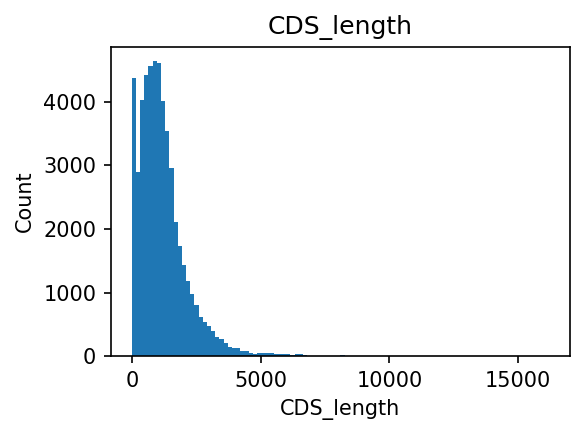

CDS_length
count    52270.000000
mean      1199.740329
std       1004.374193
min          0.000000
25%        552.000000
50%       1014.000000
75%       1572.000000
max      16203.000000
Name: CDS_length, dtype: float64
Skewness : 2.682
Kurtosis : 17.189



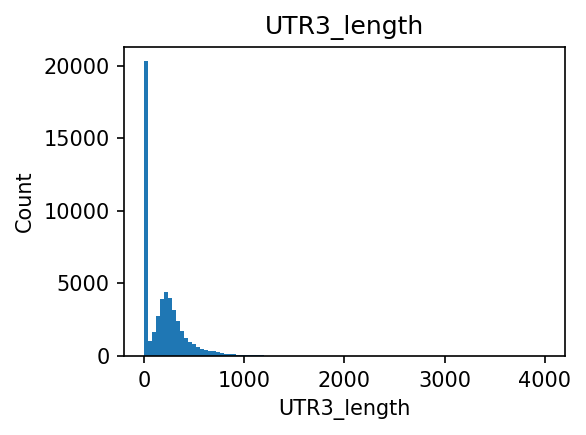

UTR3_length
count    52270.000000
mean       194.117811
std        233.879524
min          0.000000
25%          0.000000
50%        165.000000
75%        294.000000
max       4001.000000
Name: UTR3_length, dtype: float64
Skewness : 2.612
Kurtosis : 15.978



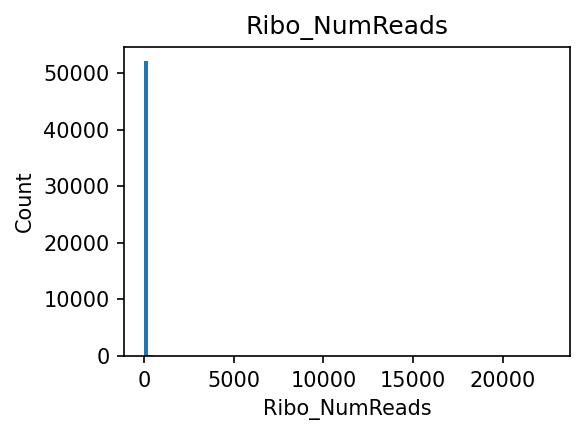

Ribo_NumReads
count    52270.000000
mean         8.199442
std        123.969496
min          0.000000
25%          0.000000
50%          0.000000
75%          2.018500
max      22636.411000
Name: Ribo_NumReads, dtype: float64
Skewness : 133.074
Kurtosis : 22475.218



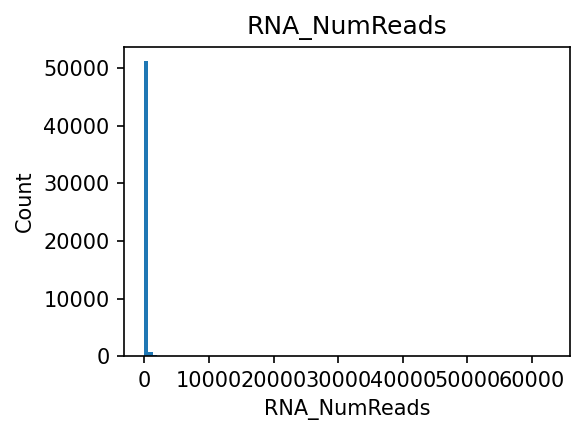

RNA_NumReads
count    52270.000000
mean        81.317680
std        494.452879
min          0.000000
25%          0.000000
50%          2.858000
75%         51.168000
max      62751.562000
Name: RNA_NumReads, dtype: float64
Skewness : 53.022
Kurtosis : 5350.590



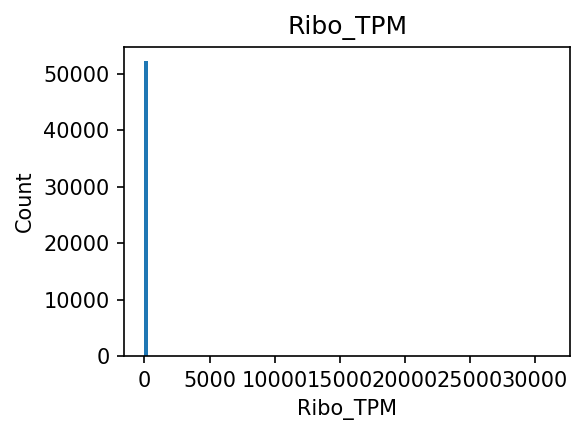

Ribo_TPM
count    52270.000000
mean         1.839925
std        141.134955
min          0.000000
25%          0.000000
50%          0.000000
75%          0.142840
max      31132.770551
Name: Ribo_TPM, dtype: float64
Skewness : 206.466
Kurtosis : 45312.436



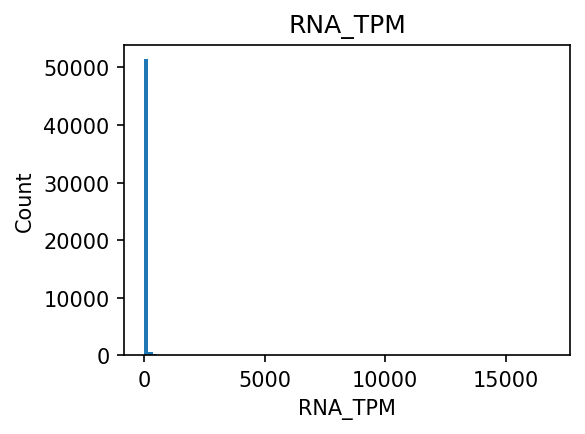

RNA_TPM
count    52270.000000
mean        18.489518
std        147.059798
min          0.000000
25%          0.000000
50%          0.596509
75%          9.358027
max      16827.495437
Name: RNA_TPM, dtype: float64
Skewness : 50.469
Kurtosis : 4239.547



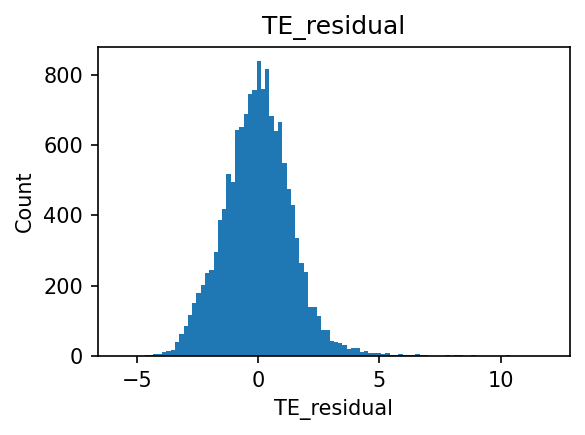

TE_residual
count    14548.000000
mean         0.001576
std          1.441142
min         -5.725898
25%         -0.915398
50%         -0.012515
75%          0.879960
max         11.971135
Name: TE_residual, dtype: float64
Skewness : 0.576
Kurtosis : 2.810



In [9]:
# ============================================
# Distribution of numeric features
# ============================================

import matplotlib.pyplot as plt

numeric_cols = [
    "Transcript_length",
    "UTR5_length",
    "CDS_length",
    "UTR3_length",
    "Ribo_NumReads",
    "RNA_NumReads",
    "Ribo_TPM",
    "RNA_TPM",
    "TE_residual",
]

for col in numeric_cols:

    data = master[col].dropna()

    plt.figure(figsize=(4,3), dpi=150)

    plt.hist(
        data,
        bins=100,
    )

    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    print("=" * 80)
    print(col)
    print(data.describe())

    print(f"Skewness : {data.skew():.3f}")
    print(f"Kurtosis : {data.kurtosis():.3f}")
    print()

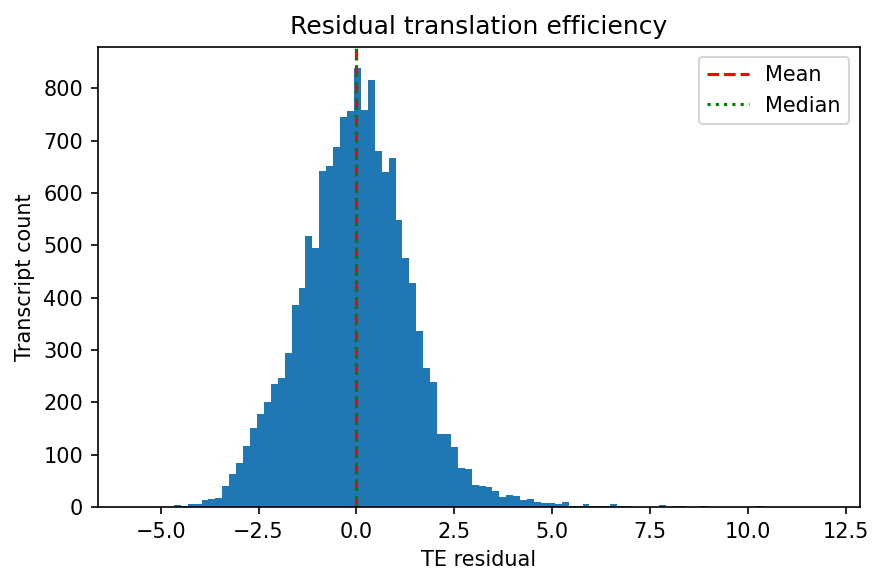

In [10]:
plt.figure(figsize=(6,4), dpi=150)

plt.hist(master["TE_residual"].dropna(), bins=100)

plt.axvline(
    master["TE_residual"].mean(),
    color="red",
    linestyle="--",
    label="Mean",
)

plt.axvline(
    master["TE_residual"].median(),
    color="green",
    linestyle=":",
    label="Median",
)

plt.title("Residual translation efficiency")
plt.xlabel("TE residual")
plt.ylabel("Transcript count")
plt.legend()

plt.tight_layout()
plt.show()